# Inverse OT Gap Loss for Gaussian Mixtures

This notebook generates the inverse-OT gap-loss figure. Two empirical measures are sampled from mixtures of two two-dimensional Gaussians. The observed coupling is the scaled permutation plan induced by the optimal assignment for the bilinear cost
$$
    c_{A_\star}(x,y)=\langle A_\star x,y\rangle,\qquad A_\star=-I.
$$
The inverse-OT loss is the unregularized Fenchel--Young gap
$$
    \mathcal L_{\mathrm{iOT}}(C(A);\widehat P)
    =\langle C(A),\widehat P\rangle
    -\min_{P\in\mathbf U(a,b)}\langle C(A),P\rangle.
$$
For equal weights, $\widehat P$ lies in the scaled Birkhoff polytope $\mathcal B_n/n$, so this is the excess Kantorovich cost of the observed coupling. Along a linear path of matrices, the loss is convex and piecewise affine.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate notebooks-figures/figure_style.py")

sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from scipy.optimize import linear_sum_assignment

from figure_style import (
    BLUE,
    RED,
    VIOLET,
    GRAY,
    DIRAC_MARKER_SIZE,
    draw_point_clouds,
    draw_transport_segments,
    figure_dir,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

FIGURE_NAME = "inverse-ot-gap-loss"
OUTPUT_DIR = figure_dir(FIGURE_NAME)
THUMBNAIL_DIR = FIGROOT / "thumbnails"
THUMBNAIL_DIR.mkdir(parents=True, exist_ok=True)


## Gaussian-mixture samples

The source and target clouds both contain $n$ points. Each cloud is sampled from a balanced mixture of two anisotropic Gaussians. The target mixture is displaced and tilted so the recovered assignment is visually readable while still being nontrivial.

In [2]:
POINT_COUNTS = (20, 100)
TRUE_A = -np.eye(2)
PATH_GRID = np.linspace(-1.0, 1.0, 241)
PATH_T0_INDEX = int(np.argmin(np.abs(PATH_GRID)))
assert np.isclose(PATH_GRID[PATH_T0_INDEX], 0.0)

SOURCE_MEANS = np.array([[-1.20, -0.55], [1.05, 0.65]])
TARGET_MEANS = np.array([[-0.95, 0.85], [1.25, -0.55]])

SOURCE_COVS = (
    np.array([[0.12, 0.045], [0.045, 0.080]]),
    np.array([[0.095, -0.035], [-0.035, 0.13]]),
)
TARGET_COVS = (
    np.array([[0.090, -0.030], [-0.030, 0.12]]),
    np.array([[0.12, 0.040], [0.040, 0.085]]),
)


def sample_balanced_mixture(n, *, means, covs, seed):
    """Sample n points from a balanced two-component Gaussian mixture."""
    rng = np.random.default_rng(seed)
    counts = (n // 2, n - n // 2)
    components = [
        rng.multivariate_normal(mean, cov, count)
        for mean, cov, count in zip(means, covs, counts)
    ]
    points = np.vstack(components)
    return points[rng.permutation(n)]


def gaussian_mixture_pair(n):
    source = sample_balanced_mixture(
        n, means=SOURCE_MEANS, covs=SOURCE_COVS, seed=1200 + n
    )
    target = sample_balanced_mixture(
        n, means=TARGET_MEANS, covs=TARGET_COVS, seed=2200 + n
    )
    return source, target


cloud_pairs = {n: gaussian_mixture_pair(n) for n in POINT_COUNTS}


## Gap loss along an anisotropic path

For each $n$, the observed plan $\widehat P$ is the scaled permutation plan induced by the optimal assignment for $A_\star=-I$. The candidate path is
$$
    A_t=-\operatorname{diag}(1+t,1-t),\qquad -1\leq t\leq 1,
$$
so that $t=0$ recovers the generating matrix. A flat zero interval can appear for small samples because the same observed coupling remains optimal for a cone of nearby costs.


In [3]:
def candidate_matrix(t):
    """Return A_t=-diag(1+t, 1-t)."""
    return -np.diag([1.0 + t, 1.0 - t])


def cost_matrix(source, target, A):
    """Return C_ij(A)=<A x_i, y_j>."""
    return source @ A.T @ target.T


def assignment_from_cost(cost):
    """Return the permutation minimizing an equal-weight assignment cost."""
    rows, cols = linear_sum_assignment(cost)
    assignment = np.empty(cost.shape[0], dtype=int)
    assignment[rows] = cols
    return assignment


def assignment_value(cost, assignment):
    """Average cost of the scaled permutation plan."""
    return float(cost[np.arange(len(assignment)), assignment].mean())


def optimal_assignment_value(cost):
    return assignment_value(cost, assignment_from_cost(cost))


def solve_assignment(source, target, A):
    return assignment_from_cost(cost_matrix(source, target, A))


def inverse_ot_gap(source, target, observed_assignment, A):
    """Compute L_iOT(C(A); P_hat) for one candidate matrix."""
    cost = cost_matrix(source, target, A)
    observed_value = assignment_value(cost, observed_assignment)
    optimal_value = optimal_assignment_value(cost)
    return max(observed_value - optimal_value, 0.0)


def iot_gap_curve(source, target, observed_assignment, t_grid):
    return np.array([
        inverse_ot_gap(source, target, observed_assignment, candidate_matrix(t))
        for t in t_grid
    ])


observed_assignments = {
    n: solve_assignment(source, target, TRUE_A)
    for n, (source, target) in cloud_pairs.items()
}
gap_losses = {
    n: iot_gap_curve(source, target, observed_assignments[n], PATH_GRID)
    for n, (source, target) in cloud_pairs.items()
}

for loss in gap_losses.values():
    assert np.isclose(loss[PATH_T0_INDEX], 0.0, atol=1e-10)


## Render figure

Panel (a) shows the observed OT bijection for $n=20$, with faint ellipses marking the Gaussian components used to sample the two clouds. Panels (b,c) plot $\mathcal{L}_{\mathrm{iOT}}(C(A_t);\widehat P)$ for $n=20$ and $n=100$ on a common vertical scale.

In [4]:
import contextlib
import io


PANEL_FILES = {
    "summary": "summary.pdf",
    "map": "observed-map-n20.pdf",
    "gap20": "gap-loss-n20.pdf",
    "gap100": "gap-loss-n100.pdf",
}

TITLE_SIZE = 8.6
LABEL_SIZE = 7.5
TICK_SIZE = 7.2


def save_panel(fig, key, *, pad_inches=0.025):
    with contextlib.redirect_stderr(io.StringIO()):
        save_pdf(fig, OUTPUT_DIR / PANEL_FILES[key], pad_inches=pad_inches)


def draw_component_ellipses(ax, means, covs, color, *, n_std=1.35):
    """Draw the Gaussian components used to sample a point cloud."""
    for mean, cov in zip(means, covs):
        values, vectors = np.linalg.eigh(cov)
        order = np.argsort(values)[::-1]
        values = values[order]
        vectors = vectors[:, order]
        angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
        width, height = 2.0 * n_std * np.sqrt(values)
        ax.add_patch(Ellipse(
            mean, width, height, angle=angle,
            facecolor=color, edgecolor="none", alpha=0.08, zorder=0,
        ))
        ax.add_patch(Ellipse(
            mean, width, height, angle=angle,
            facecolor="none", edgecolor=color, lw=0.55, alpha=0.32, zorder=0.5,
        ))


def draw_observed_map(ax, source, target, assignment):
    pairs = [(i, int(j), 1.0 / len(source)) for i, j in enumerate(assignment)]
    draw_component_ellipses(ax, SOURCE_MEANS, SOURCE_COVS, RED)
    draw_component_ellipses(ax, TARGET_MEANS, TARGET_COVS, BLUE)
    draw_transport_segments(
        ax,
        source,
        target,
        pairs,
        color=VIOLET,
        min_width=0.34,
        max_width=0.34,
        alpha_scale=0.34,
        zorder=1,
    )
    draw_point_clouds(ax, source, target, base_size=DIRAC_MARKER_SIZE * 1.12)
    xlim, ylim = padded_limits(np.vstack([source, target]), pad=0.23)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_gap(ax, n, *, ylim, panel_label, show_ylabel=False):
    loss = gap_losses[n]
    ax.axhline(0.0, color="#bbbbbb", lw=0.55, zorder=0)
    ax.plot(PATH_GRID, loss, color=VIOLET, lw=1.65)
    ax.axvline(0.0, color=GRAY, lw=0.75, ls="--", alpha=0.75)
    ax.scatter([0.0], [loss[PATH_T0_INDEX]], s=17, color=RED, zorder=3)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(*ylim)
    ax.set_xlabel(
        r"$t$ along $A_t=-\mathrm{diag}(1+t,1-t)$",
        fontsize=LABEL_SIZE,
        labelpad=2.0,
    )
    if show_ylabel:
        ax.set_ylabel(
            r"$\mathcal{L}_{\mathrm{iOT}}(C(A_t);\widehat{P})$",
            fontsize=LABEL_SIZE,
            labelpad=3.0,
        )
    ax.set_title(
        fr"({panel_label}) iOT gap loss, $n={n}$",
        fontsize=TITLE_SIZE,
        color=GRAY,
        pad=2.0,
    )
    ax.grid(True, color="#eeeeee", lw=0.55)
    ax.tick_params(axis="both", labelsize=TICK_SIZE, width=0.6, length=2.5, pad=1.5)
    for spine in ax.spines.values():
        spine.set_linewidth(0.65)


gap_ymax = max(float(loss.max()) for loss in gap_losses.values())
gap_ylim = (-0.025 * gap_ymax, 1.04 * gap_ymax)
source20, target20 = cloud_pairs[20]
fig, axes = plt.subplots(
    1,
    3,
    figsize=(8.45, 2.22),
    gridspec_kw={"width_ratios": [1.05, 1.0, 1.0]},
)
draw_observed_map(axes[0], source20, target20, observed_assignments[20])
draw_gap(axes[1], 20, ylim=gap_ylim, panel_label="b", show_ylabel=True)
draw_gap(axes[2], 100, ylim=gap_ylim, panel_label="c")
fig.subplots_adjust(left=0.02, right=0.995, bottom=0.22, top=0.86, wspace=0.30)
save_panel(fig, "summary")
thumb_path = THUMBNAIL_DIR / f"{FIGURE_NAME}.png"
fig.savefig(thumb_path, dpi=240, bbox_inches="tight", pad_inches=0.035)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.65, 2.25))
draw_observed_map(ax, source20, target20, observed_assignments[20])
save_panel(fig, "map")
plt.close(fig)

for n, key in [(20, "gap20"), (100, "gap100")]:
    fig, ax = plt.subplots(figsize=(2.65, 2.25))
    draw_gap(ax, n, ylim=gap_ylim, panel_label="b" if n == 20 else "c", show_ylabel=True)
    save_panel(fig, key)
    plt.close(fig)

thumb_path


PosixPath('/Users/gpeyre/Dropbox/github/ot4ml/notebooks-figures/thumbnails/inverse-ot-gap-loss.png')

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

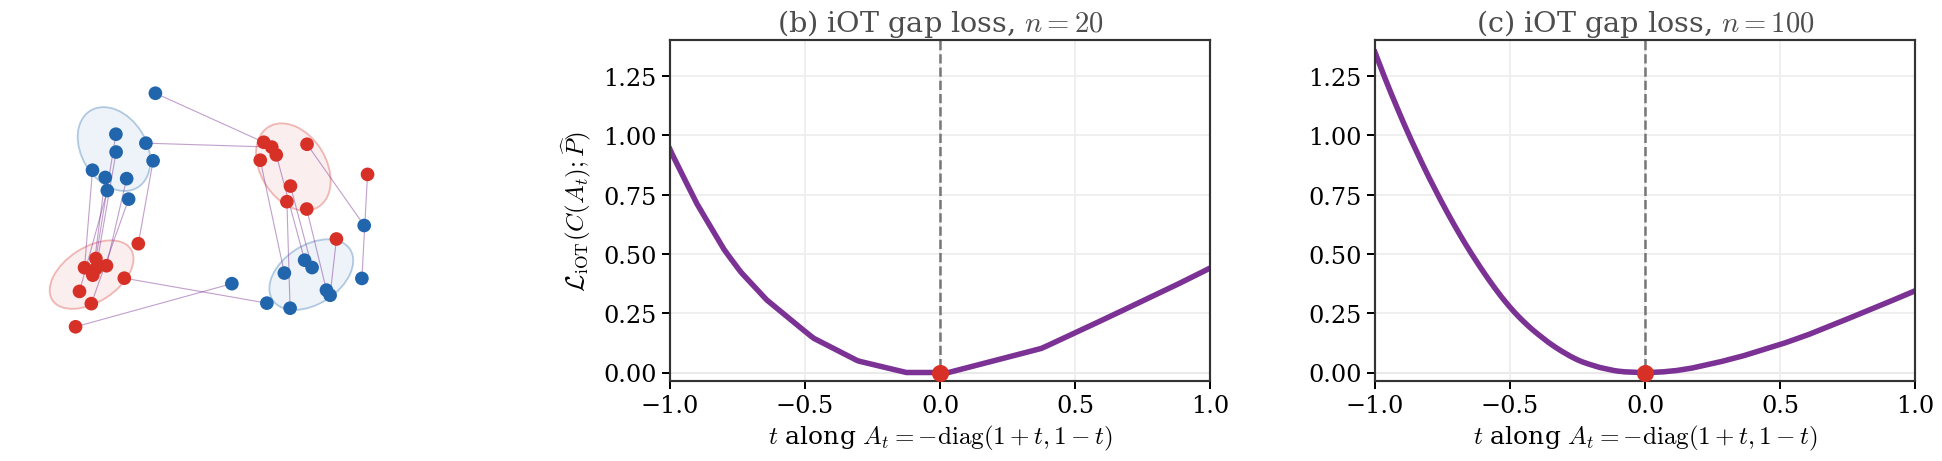

In [5]:
from IPython.display import Image, display
display(Image(filename=str(thumb_path)))
